# EDA (Exploratory Data Analysis)
- Statistical Analysis
- Data Visualization

In [20]:
# Imports

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Imports Loaded Successfully")

Imports Loaded Successfully


In [21]:
# Configuration Parameters
DATASET = "cleaned_movie_data.csv"
TARGET = "imdb_binned"

FIGURE_WIDTH = 12
FIGURE_HEIGHT = 6
TOP_N = 10

In [22]:
# Load Dataset & Initial Inspection

df = pd.read_csv(DATASET)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n--- Dataset Head ---")
print(df.head())

Rows    : 4998
Columns : 35

--- Dataset Head ---
   color      director_name  num_critic_for_reviews  duration  \
0  Color      James Cameron                   723.0     178.0   
1  Color     Gore Verbinski                   302.0     169.0   
2  Color         Sam Mendes                   602.0     148.0   
3  Color  Christopher Nolan                   813.0     164.0   
4  Color        Doug Walker                     0.0     103.0   

   director_facebook_likes  actor_3_facebook_likes      actor_2_name  \
0                      0.0                   855.0  Joel David Moore   
1                    563.0                  1000.0     Orlando Bloom   
2                      0.0                   161.0      Rory Kinnear   
3                  22000.0                 23000.0    Christian Bale   
4                    131.0                     0.0        Rob Walker   

   actor_1_facebook_likes        gross                           genres  ...  \
0                  1000.0  760505847.0  Action

In [23]:
# Dataset Overview & Data Quality Auditing
df.info()

print("\n--- Summary Statistics (Numerical) ---")
print(df.describe().T)

print("\n--- Summary Statistics (Categorical) ---")
print(df.describe(include="object").T)

# Missing Values Breakdown

missing_values = df.isnull().sum()
missing_percentage = ((missing_values / len(df)) * 100).round(2)

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing (%)": missing_percentage.values
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

print("\n--- Missing Values Audit ---")
if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print(missing_df.sort_values(by="Missing Values", ascending=False))

# Duplicate Record Analysis

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("\n--- Duplicate Audit ---")
print(f"Total Records      : {len(df)}")
print(f"Duplicate Records  : {duplicate_count}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      4998 non-null   object 
 1   director_name              4998 non-null   object 
 2   num_critic_for_reviews     4998 non-null   float64
 3   duration                   4998 non-null   float64
 4   director_facebook_likes    4998 non-null   float64
 5   actor_3_facebook_likes     4998 non-null   float64
 6   actor_2_name               4998 non-null   object 
 7   actor_1_facebook_likes     4998 non-null   float64
 8   gross                      4998 non-null   float64
 9   genres                     4998 non-null   object 
 10  actor_1_name               4998 non-null   object 
 11  num_voted_users            4998 non-null   float64
 12  cast_total_facebook_likes  4998 non-null   float64
 13  actor_3_name               4998 non-null   objec

# Target Variable Distribution


--- Target Class Counts ---
imdb_binned
HIT     3428
AVG     1524
FLOP      46
Name: count, dtype: int64


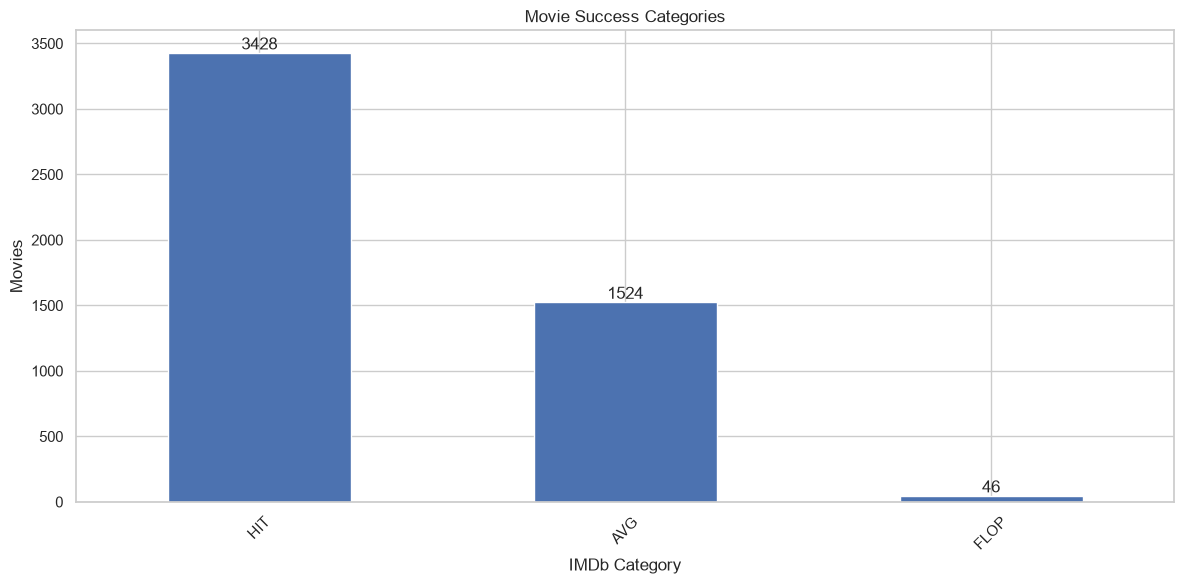

In [24]:
target_distribution = df[TARGET].value_counts()

print("\n--- Target Class Counts ---")
print(target_distribution)

plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
ax = target_distribution.plot(kind="bar")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Movie Success Categories")
plt.xlabel("IMDb Category")
plt.ylabel("Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Column Type Separation
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print(f"\nNumerical Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")


Numerical Columns (24): ['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'aspect_ratio', 'movie_facebook_likes', 'is_color', 'log_budget', 'log_gross', 'roi', 'review_ratio', 'votes_per_review', 'actor_lead_share', 'director_share', 'movie_age']
Categorical Columns (11): ['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'actor_3_name', 'plot_keywords', 'language', 'country', 'content_rating', 'imdb_binned']


# Genre Analysis (HIT vs FLOP)

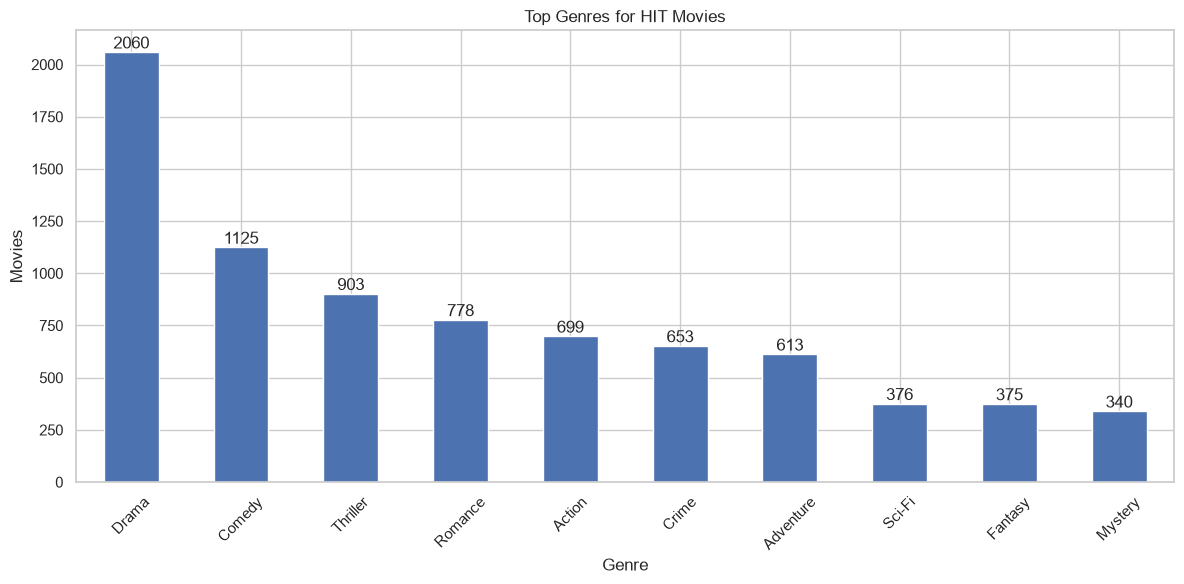

In [26]:
if "genres" in df.columns:
    genre_df = df.copy()
    genre_df["genres"] = genre_df["genres"].astype(str).str.split("|")
    genre_df = genre_df.explode("genres")

    # Top Genres for HIT Movies
    hit = (
        genre_df[genre_df[TARGET] == "HIT"]
        .groupby("genres")
        .size()
        .sort_values(ascending=False)
        .head(TOP_N)
    )

    plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    ax = hit.plot(kind="bar")

    for container in ax.containers:
        ax.bar_label(container)

    plt.title("Top Genres for HIT Movies")
    plt.xlabel("Genre")
    plt.ylabel("Movies")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Top Genres for FLOP Movies

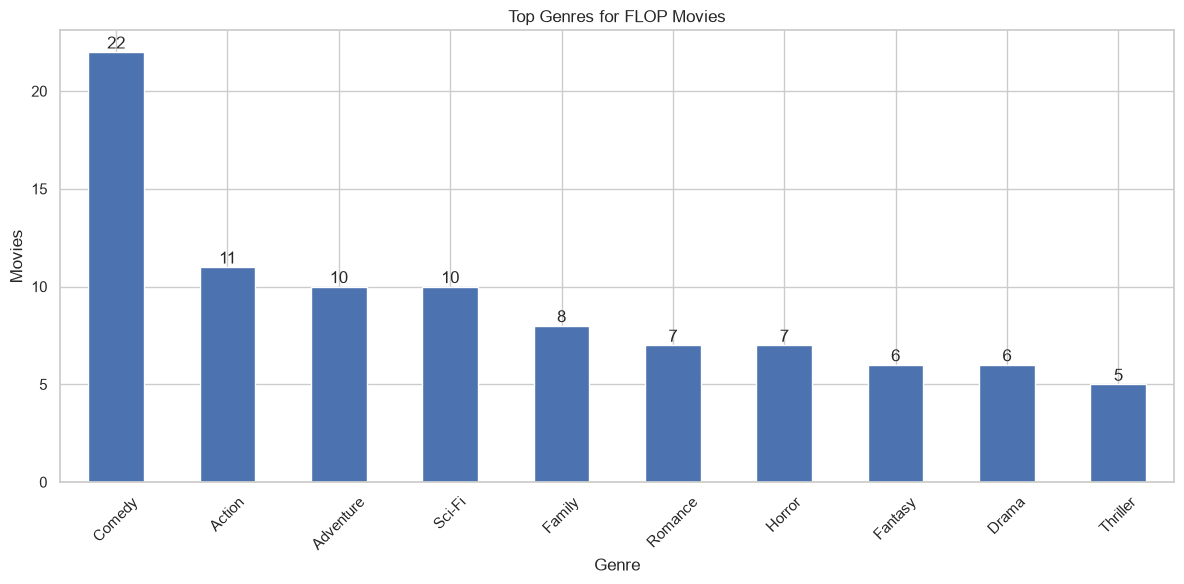

In [27]:

flop = (
        genre_df[genre_df[TARGET] == "FLOP"]
        .groupby("genres")
        .size()
        .sort_values(ascending=False)
        .head(TOP_N)
    )

plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
ax = flop.plot(kind="bar")
for container in ax.containers:
    ax.bar_label(container)

plt.title("Top Genres for FLOP Movies")
plt.xlabel("Genre")
plt.ylabel("Movies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Numerical Data Analysis (Boxplots & Scatterplots)

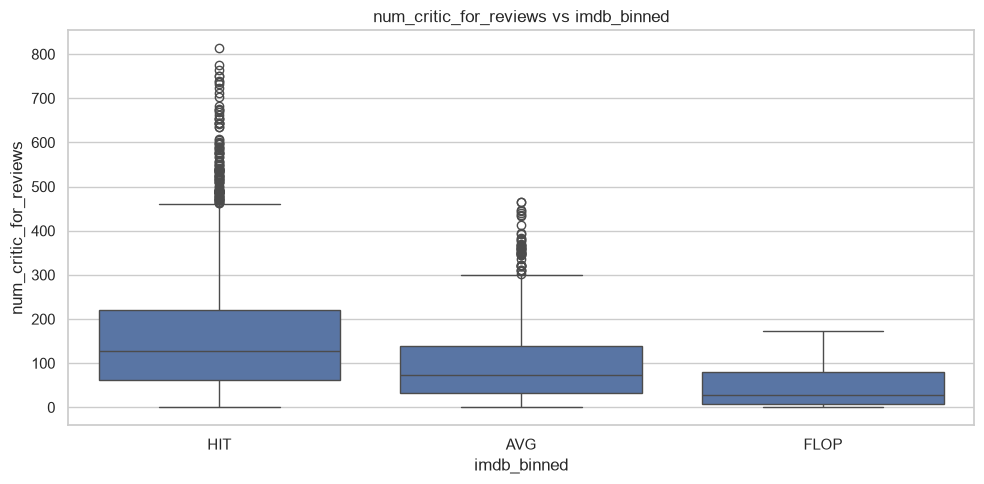

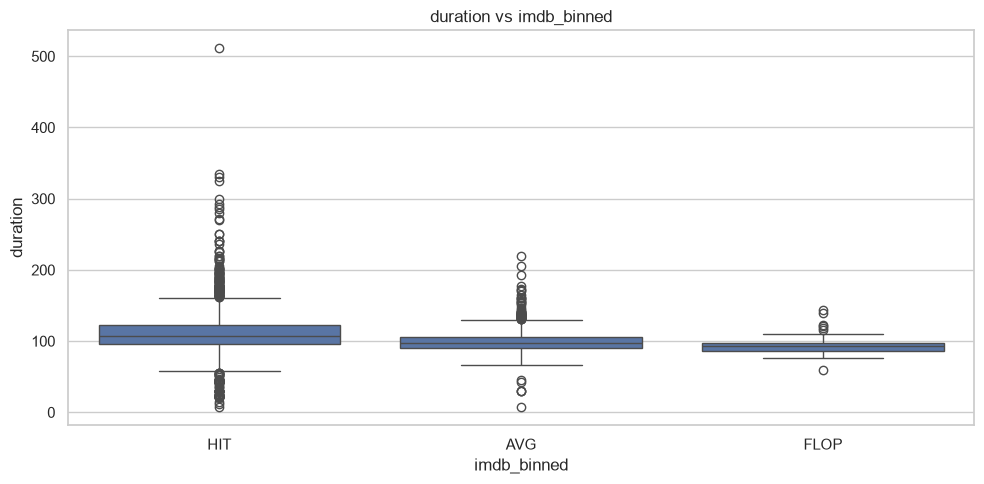

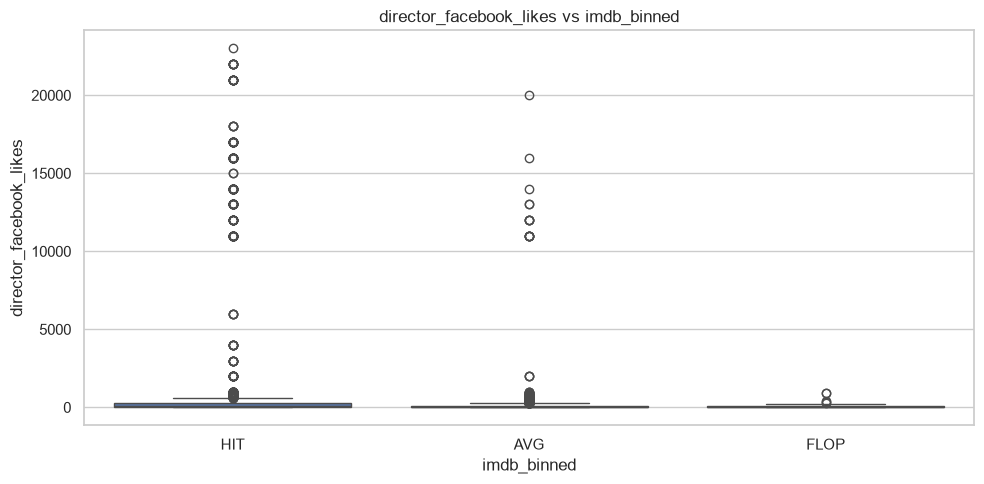

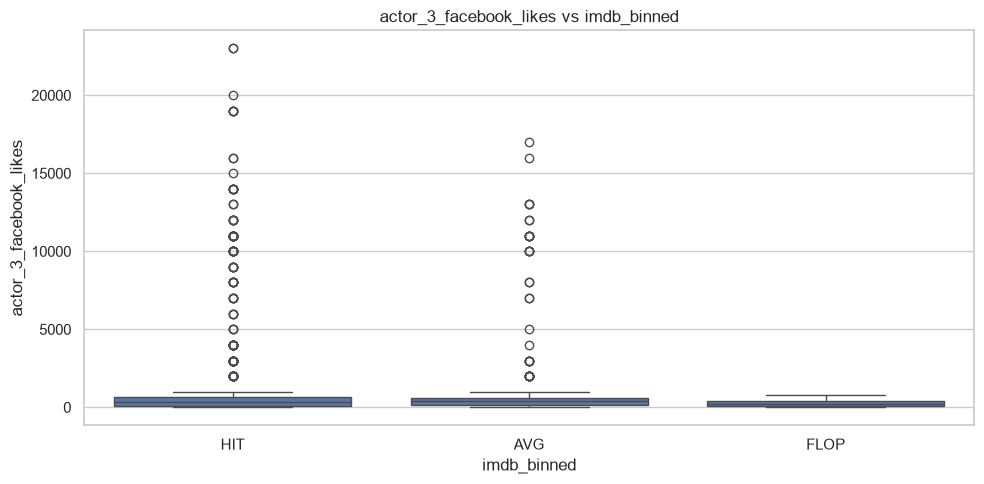

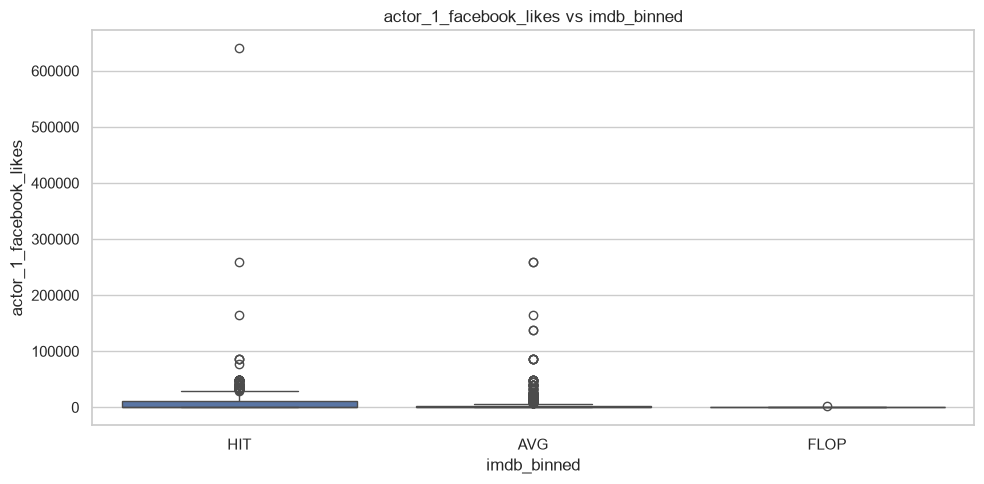

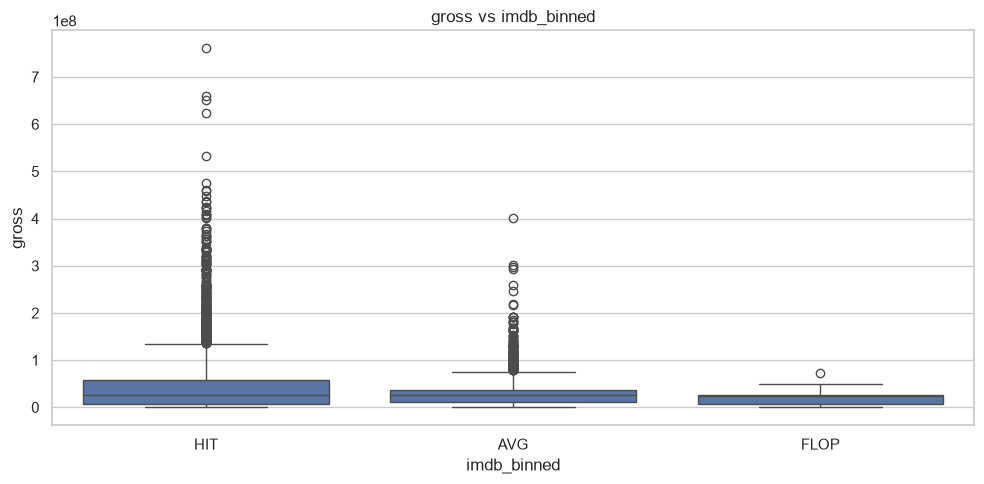

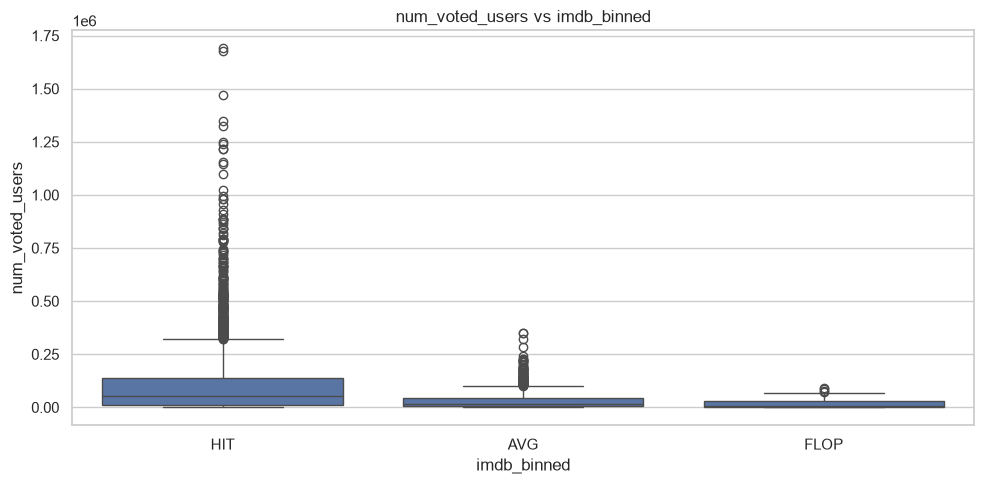

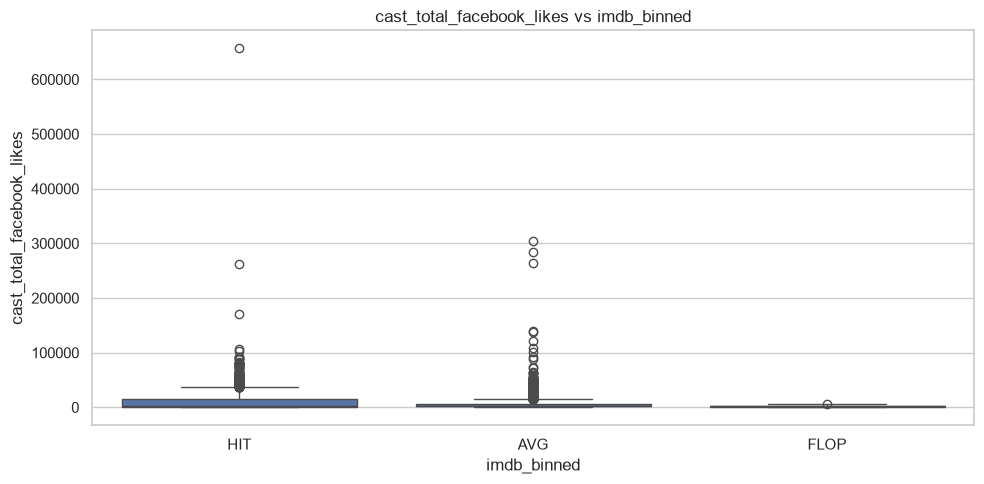

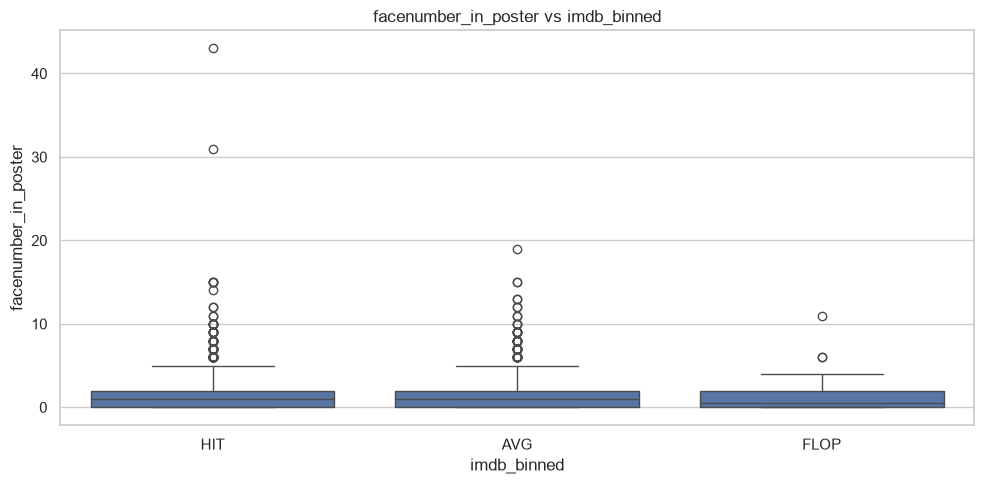

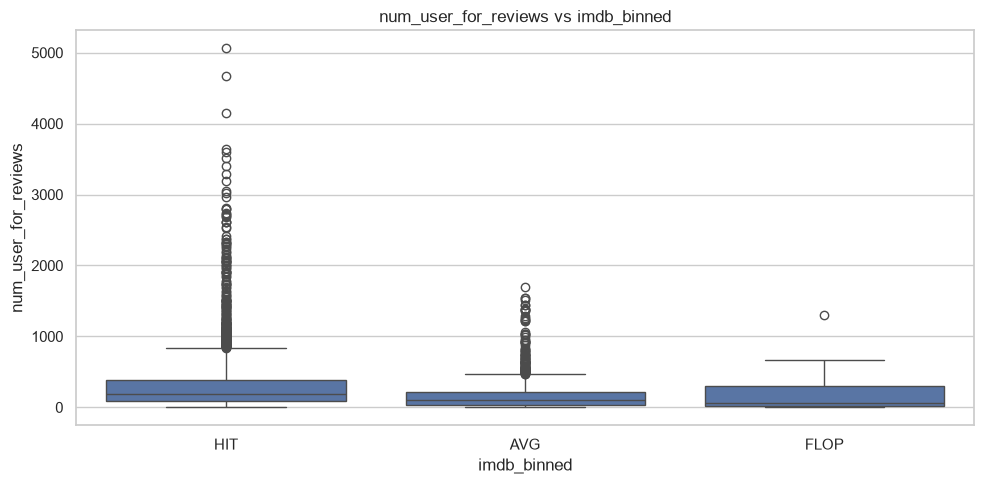

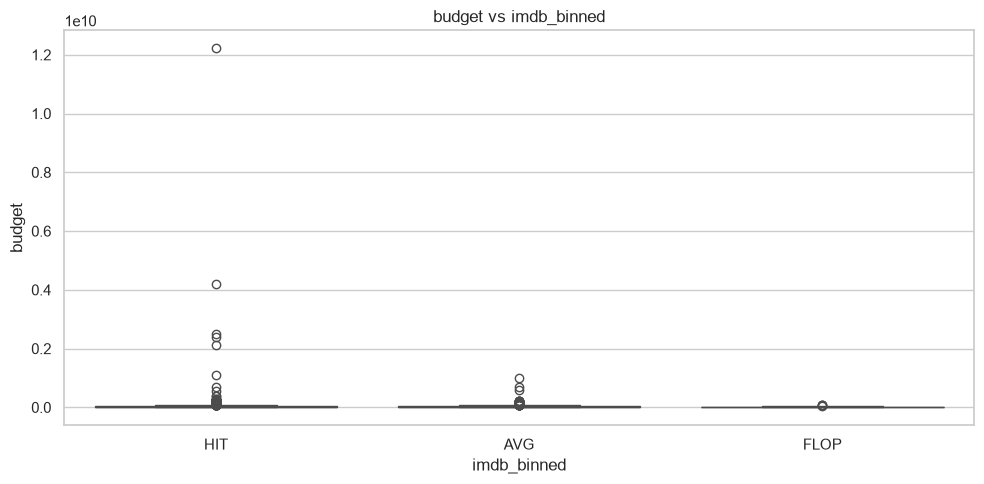

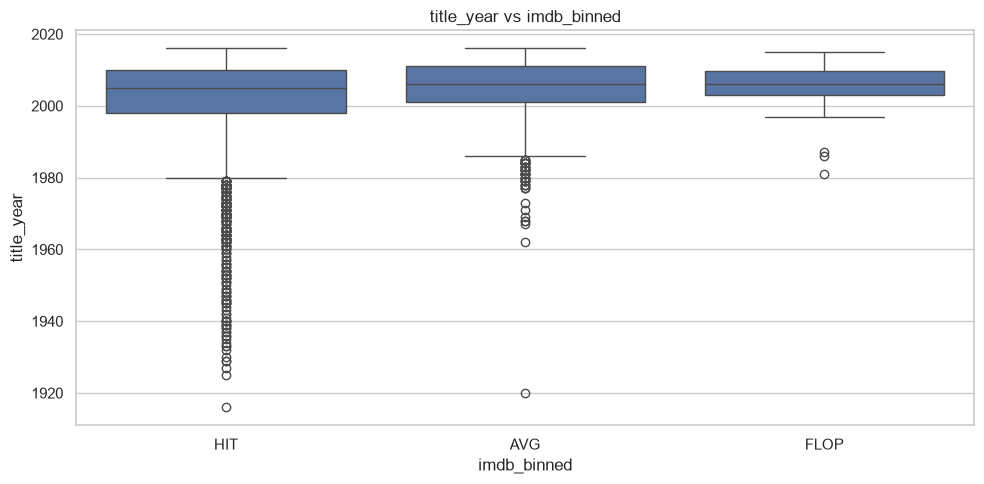

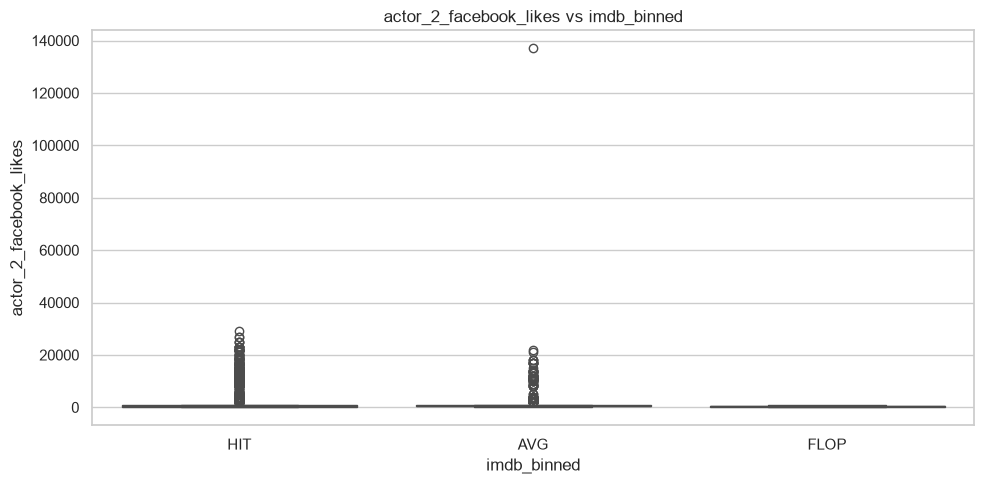

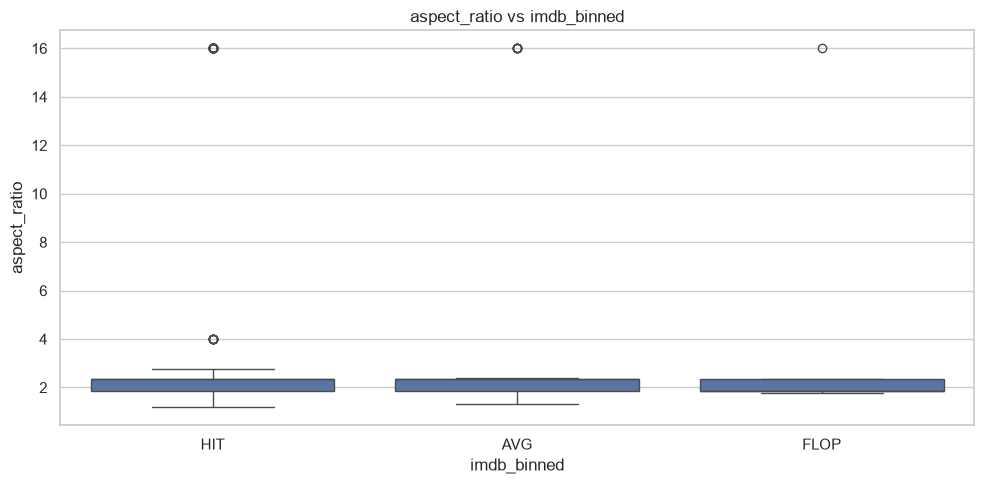

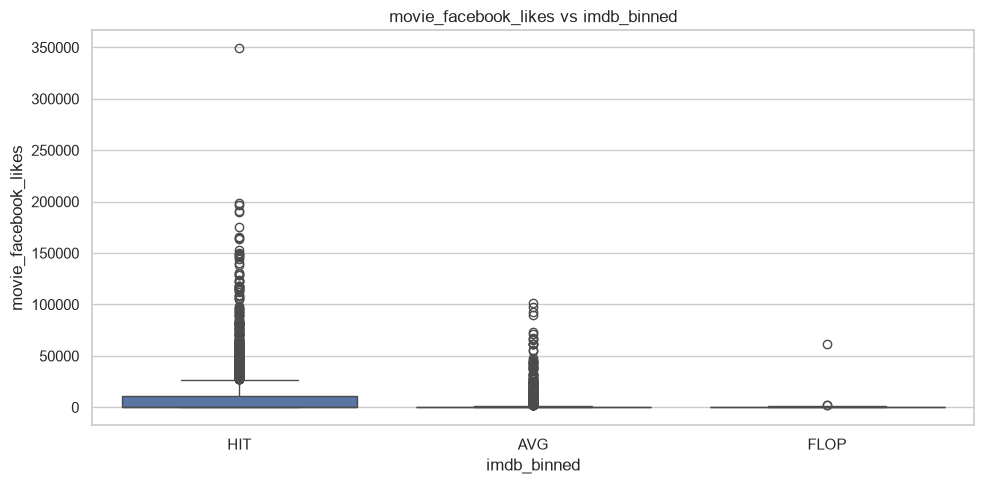

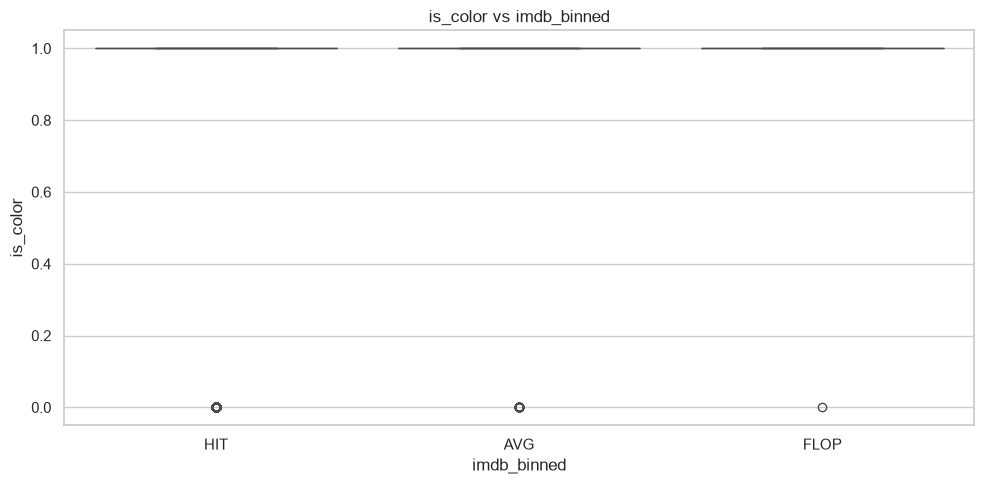

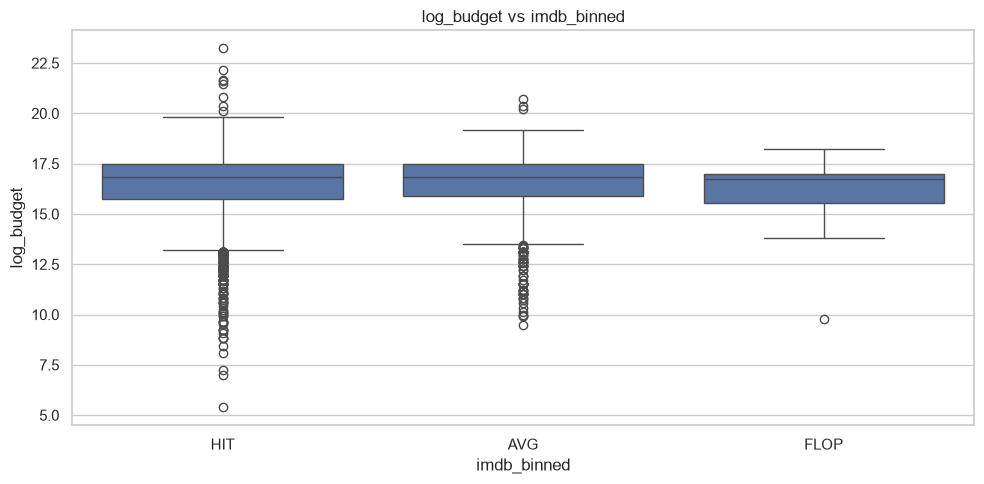

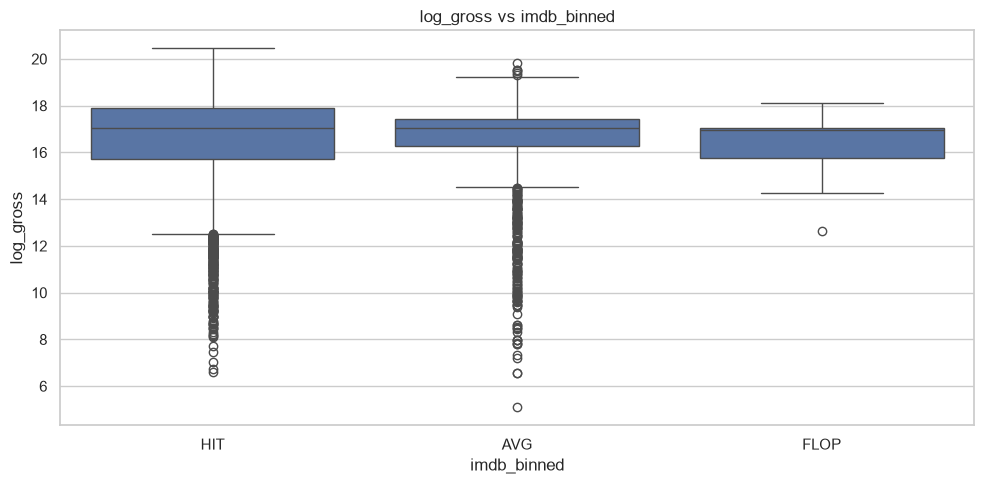

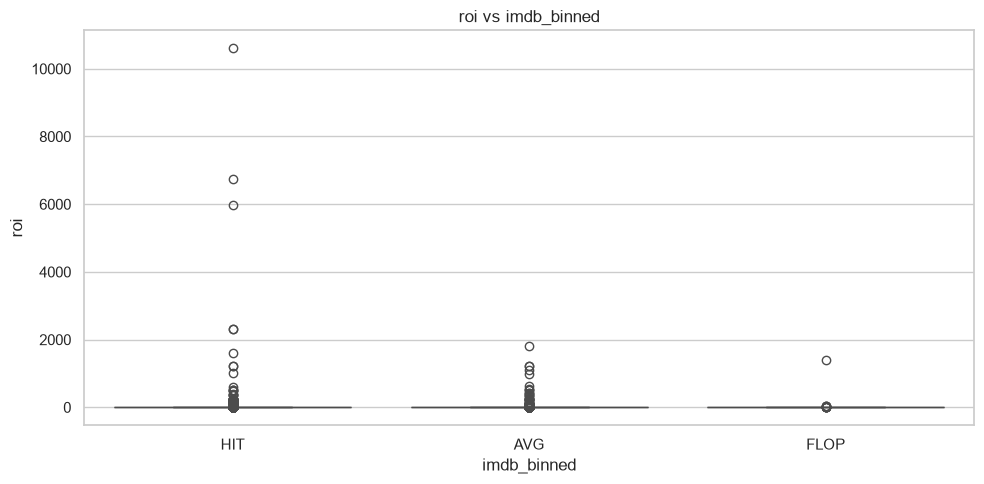

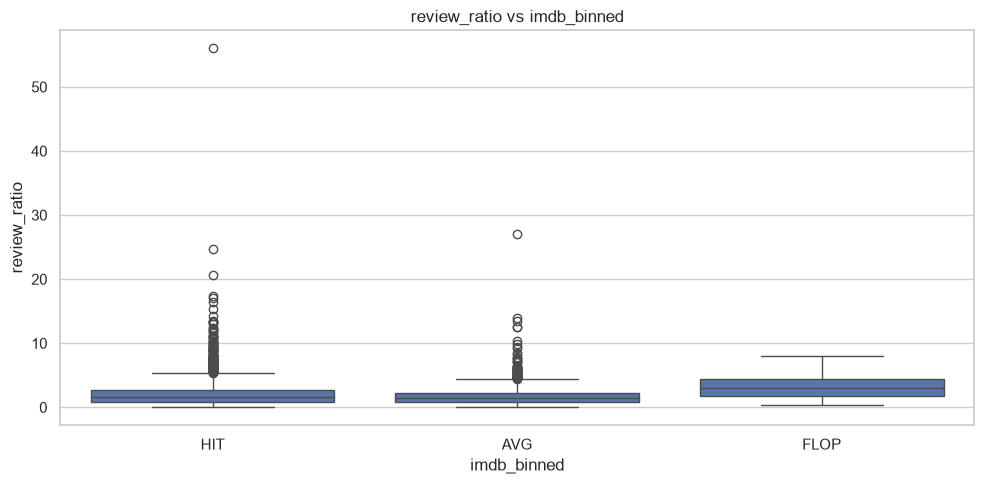

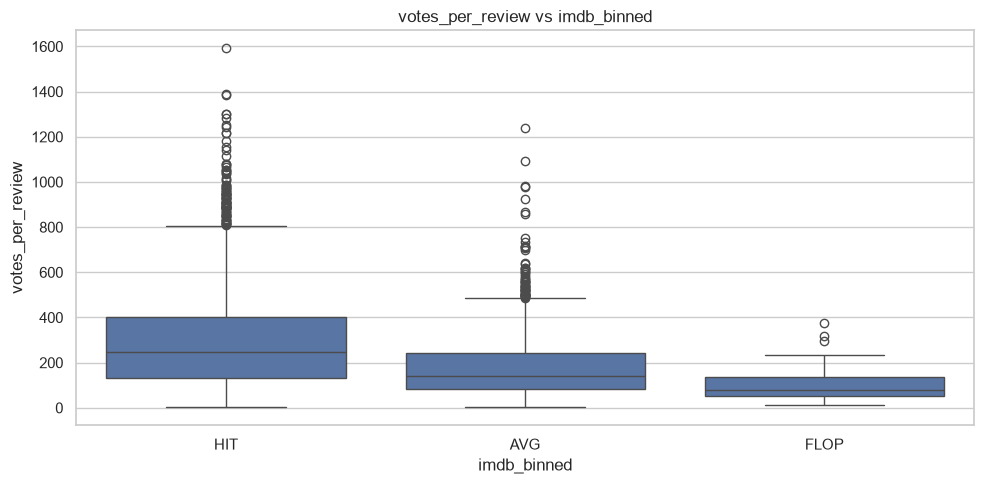

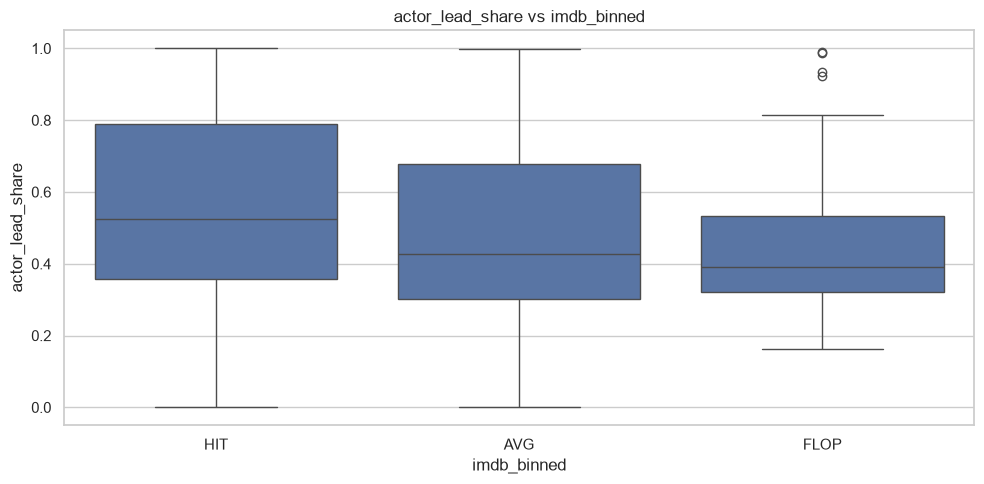

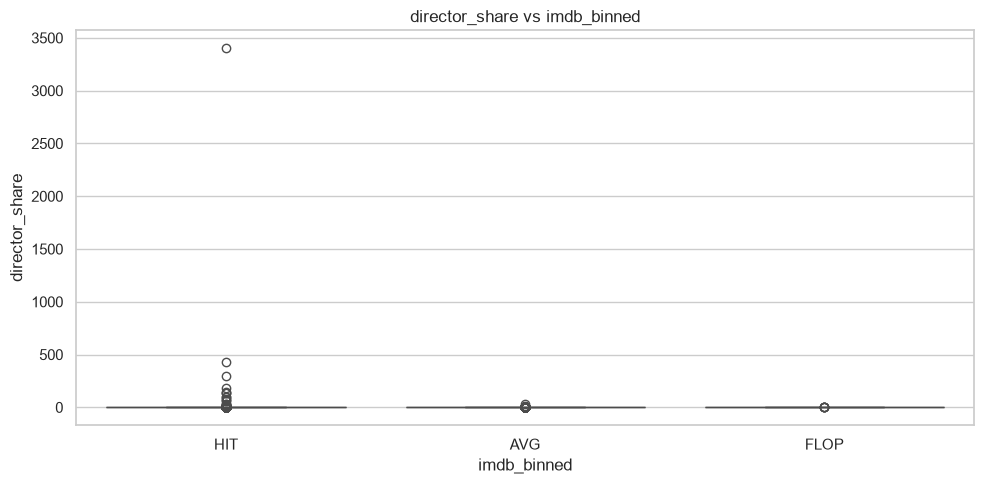

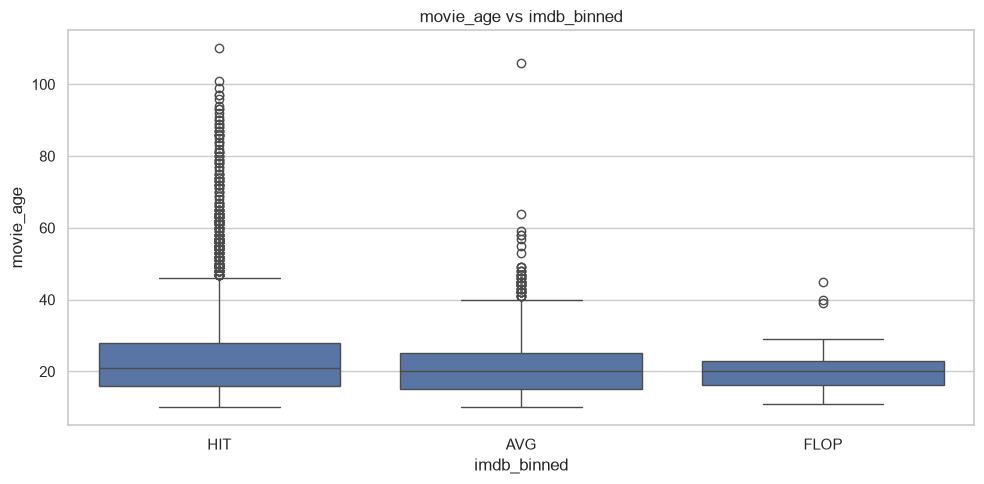

In [28]:
# Boxplot Distributions across Target Categories
for column in num_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x=TARGET, y=column)
    plt.title(f"{column} vs {TARGET}")
    plt.tight_layout()
    plt.show()

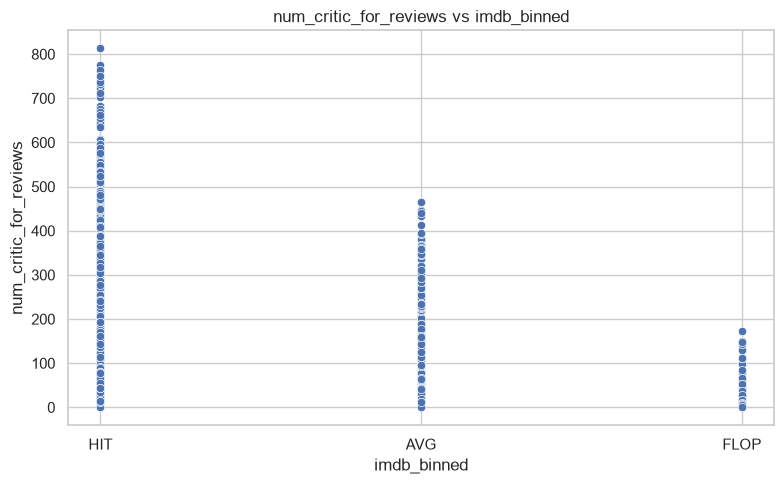

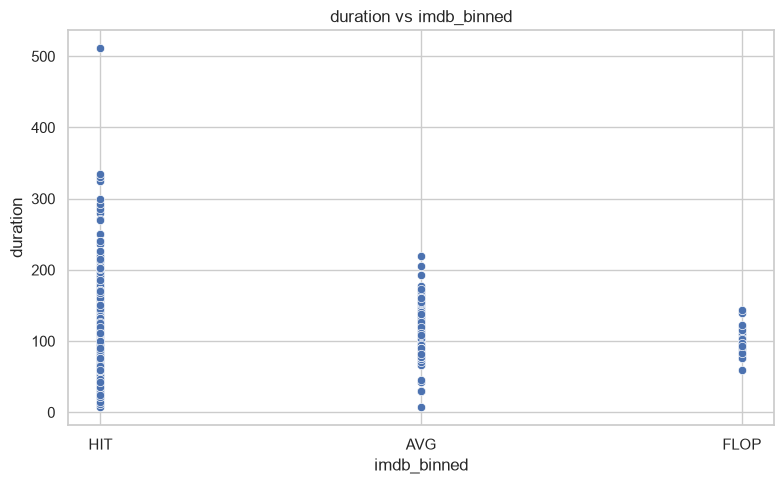

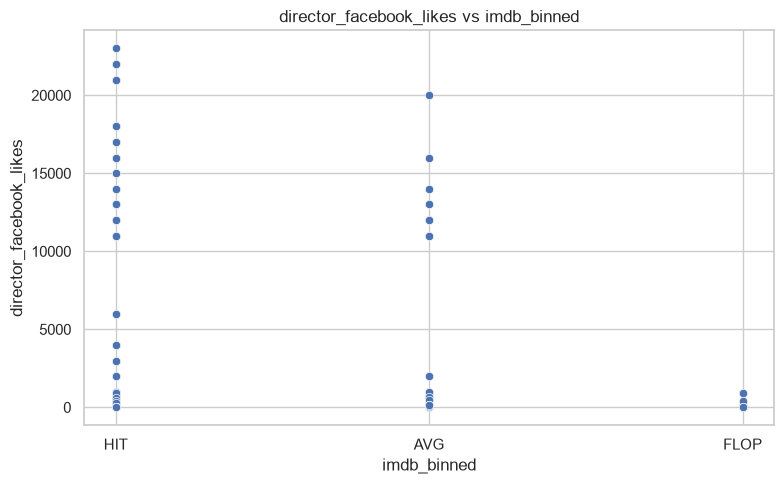

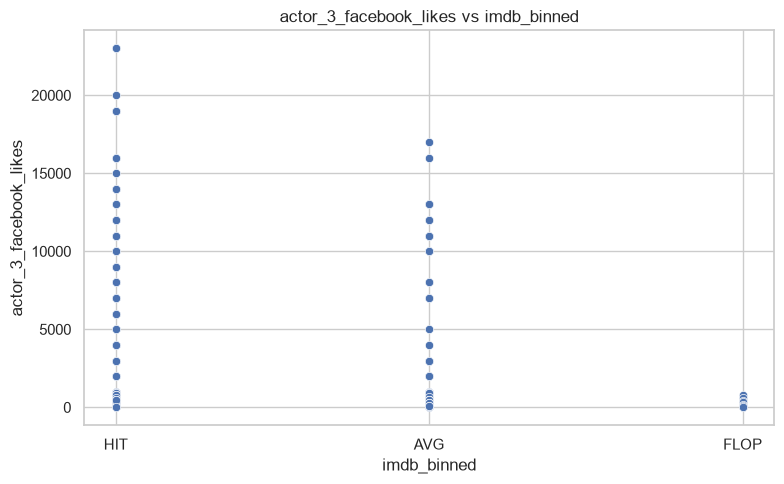

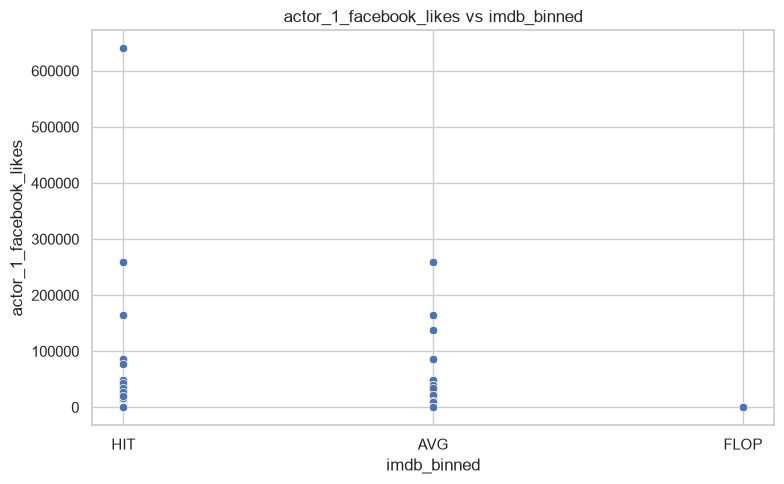

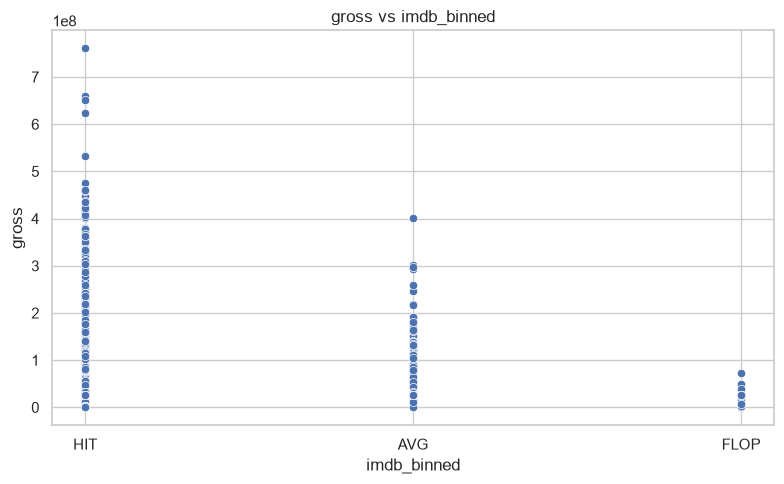

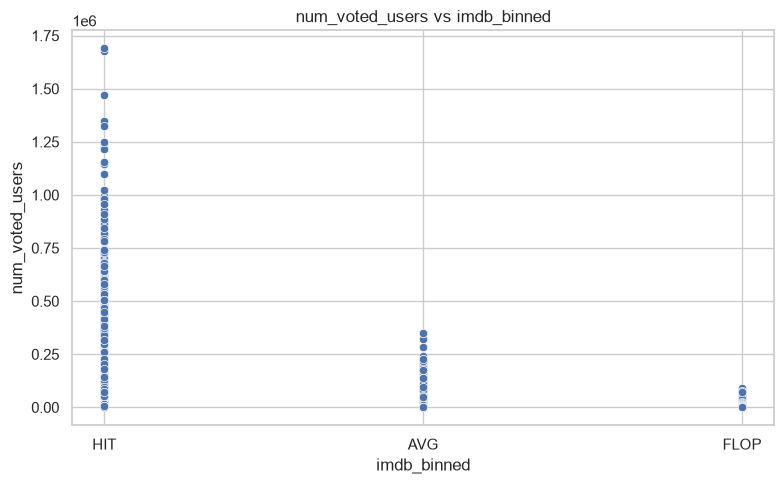

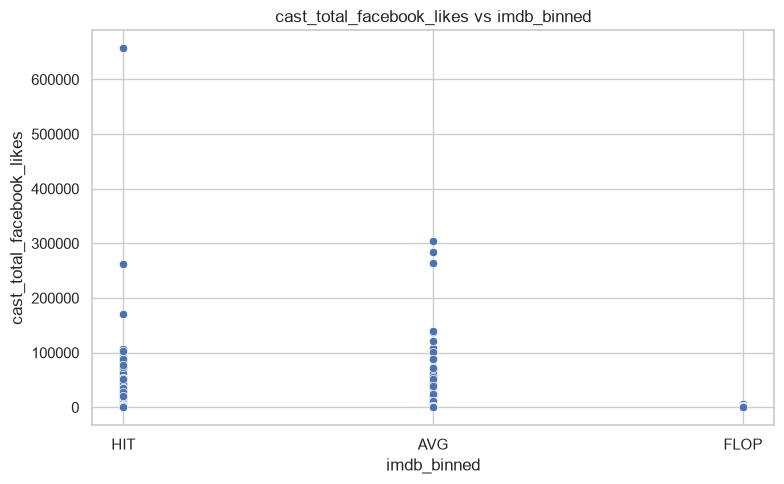

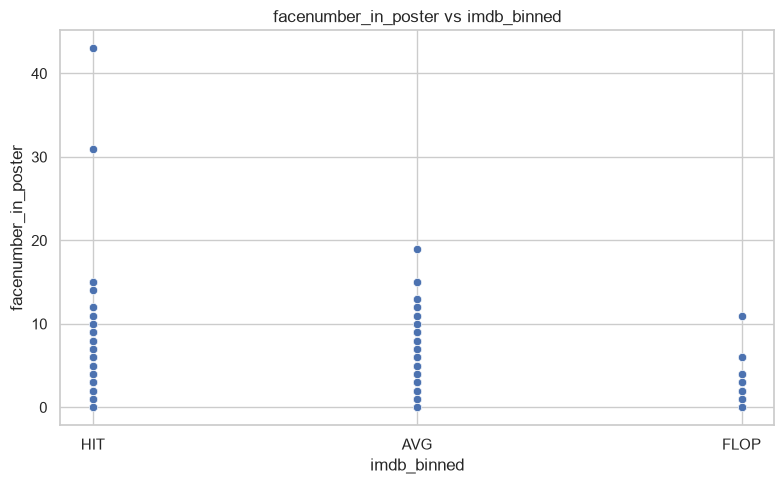

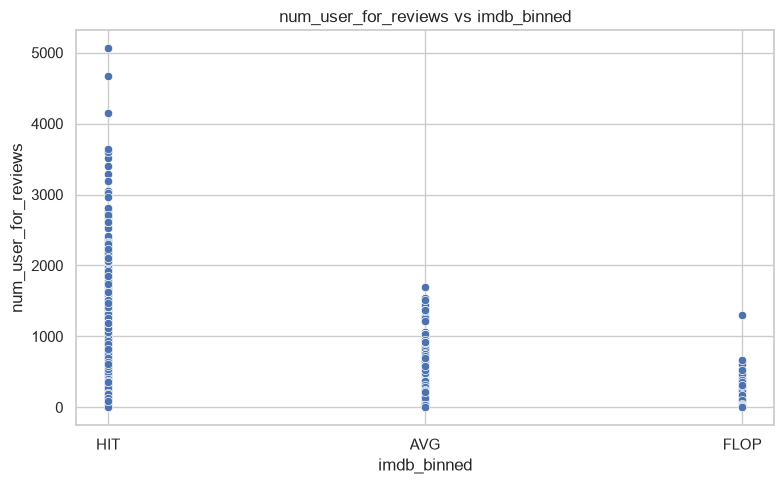

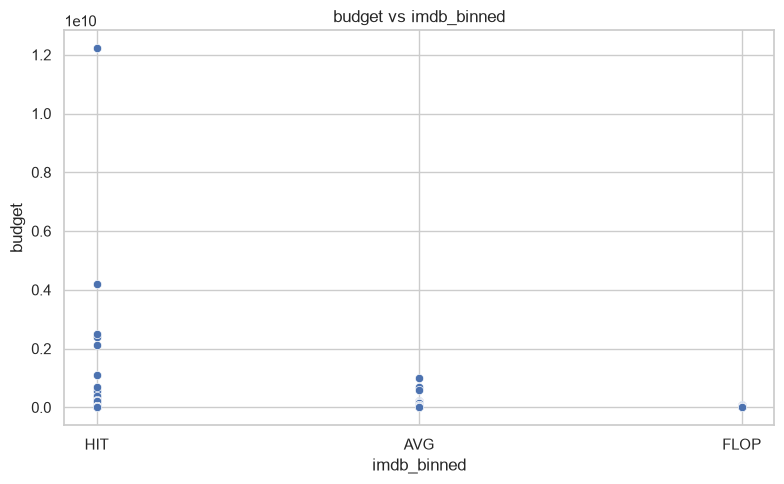

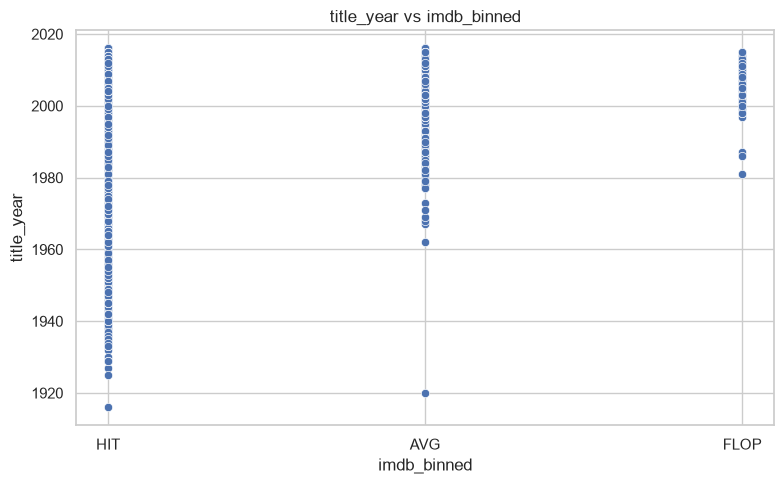

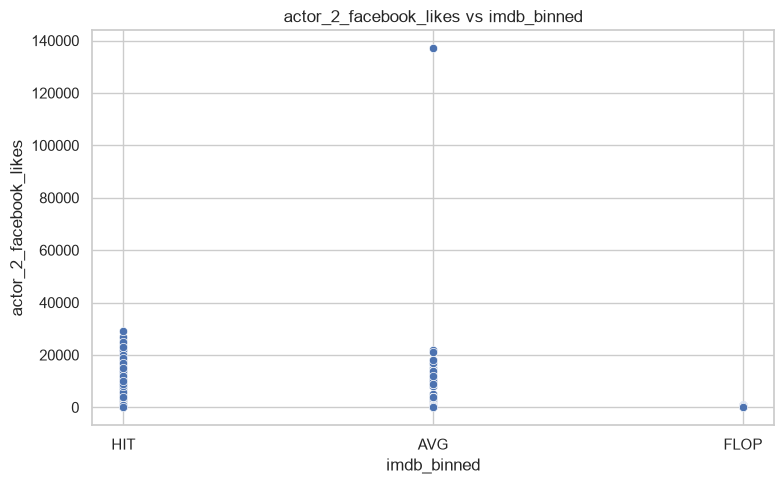

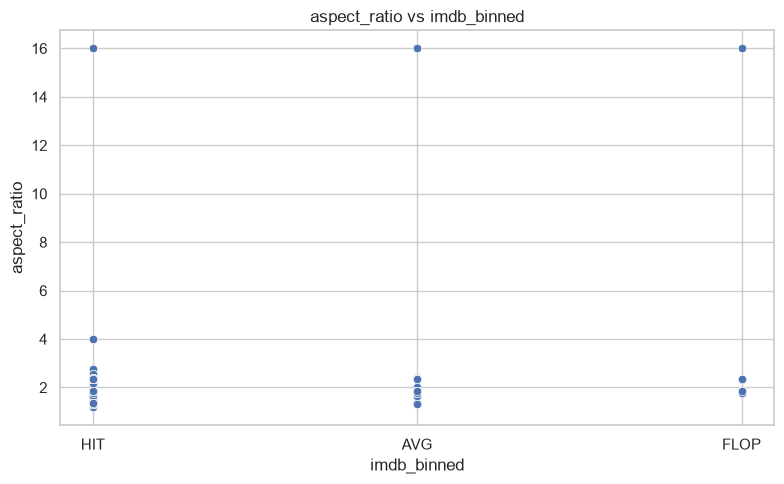

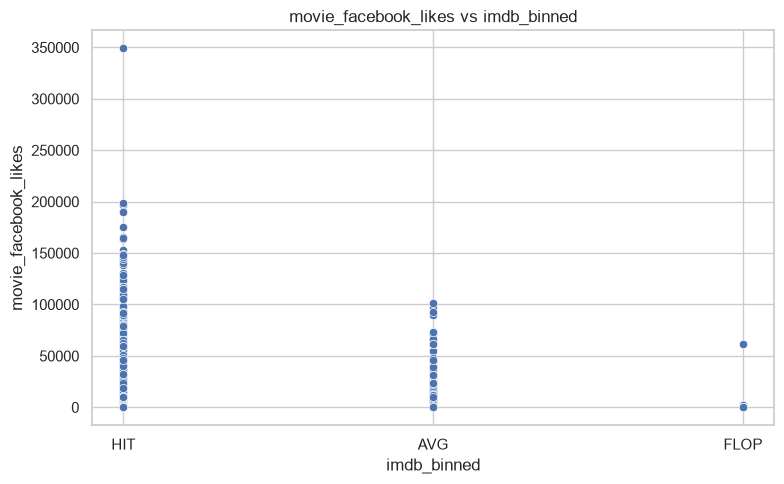

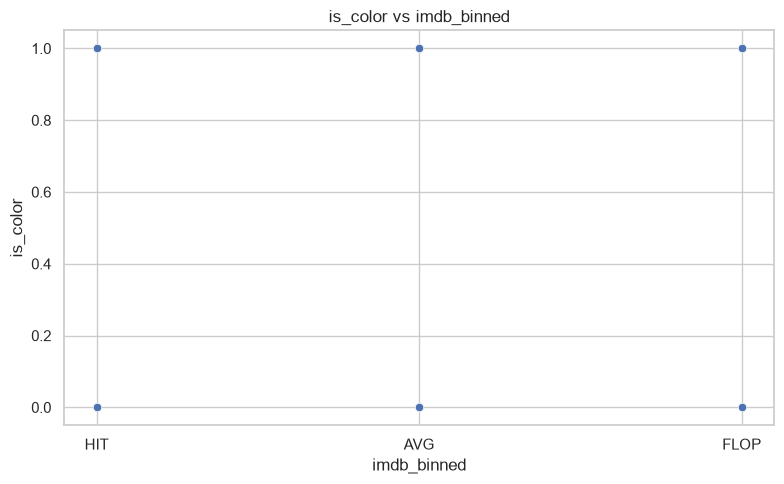

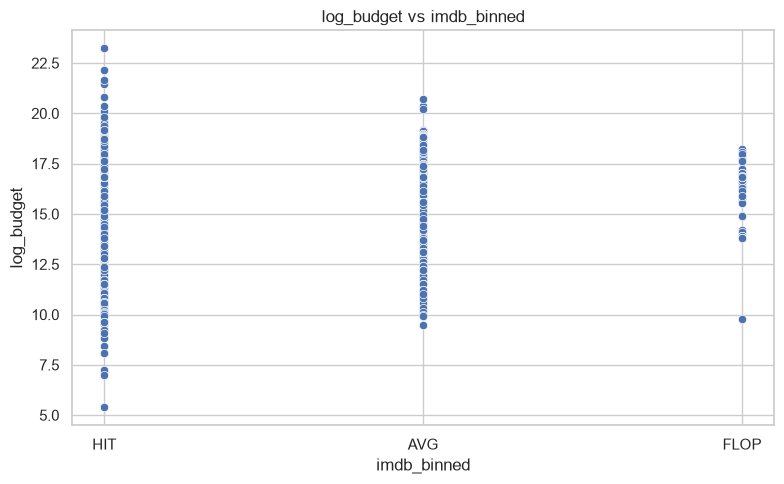

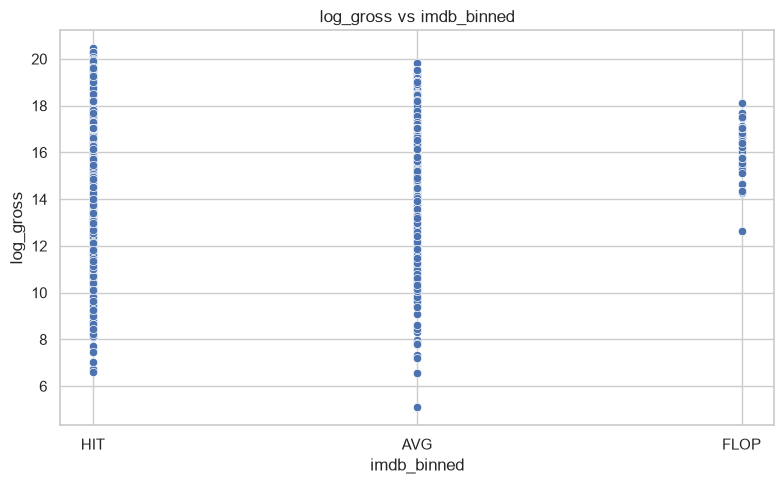

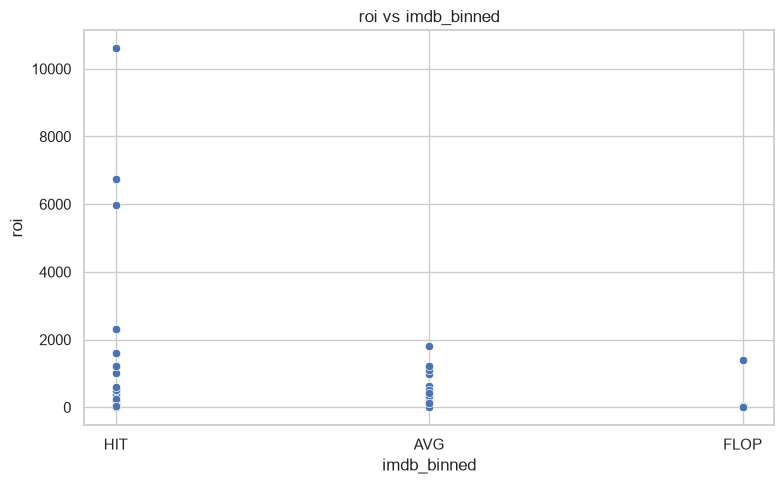

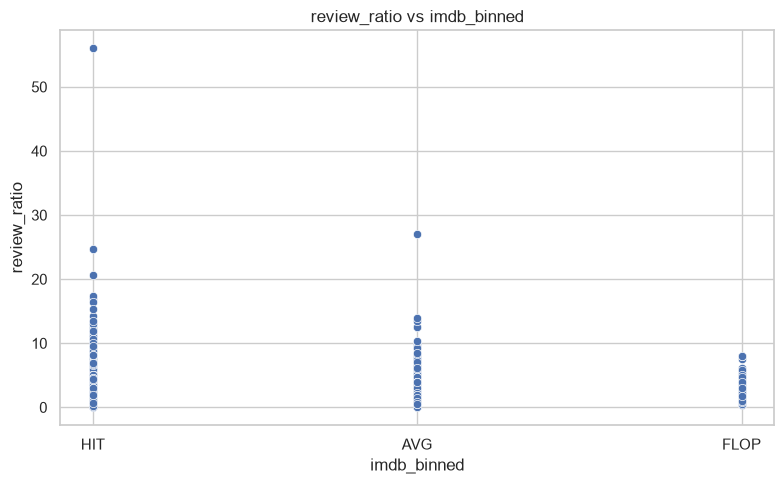

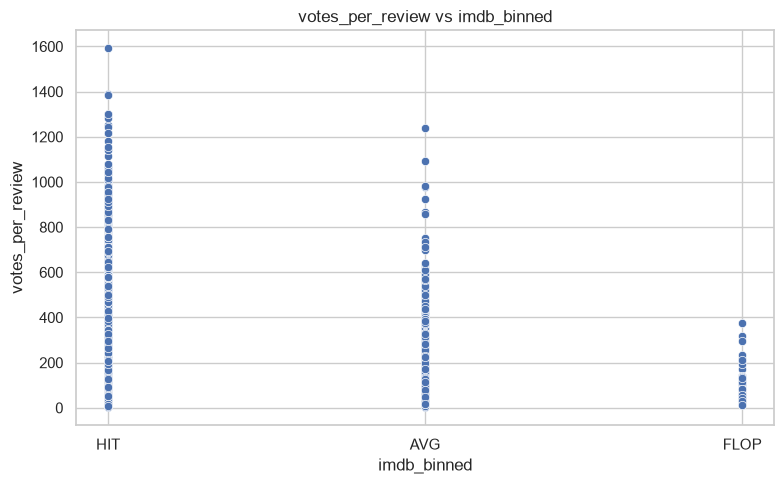

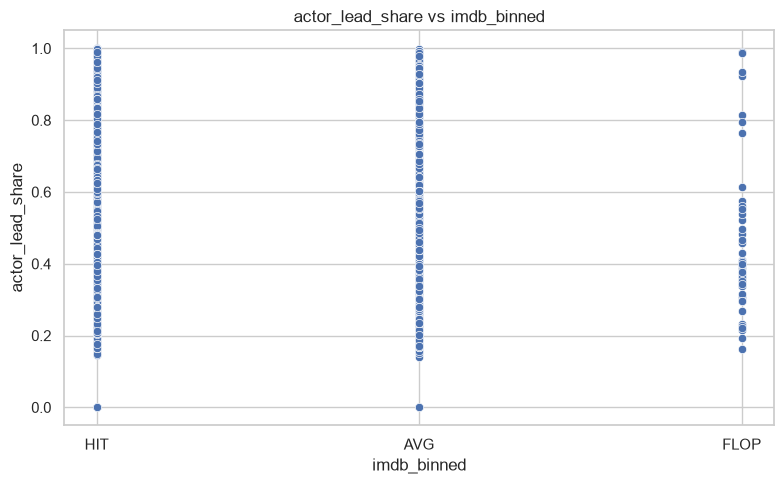

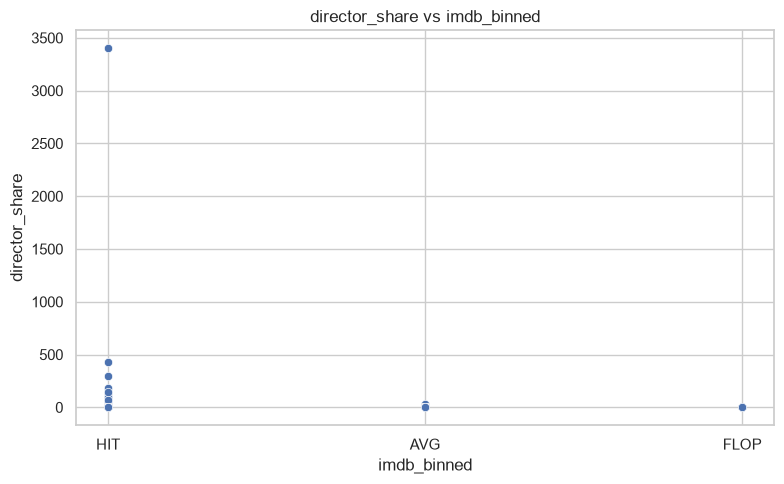

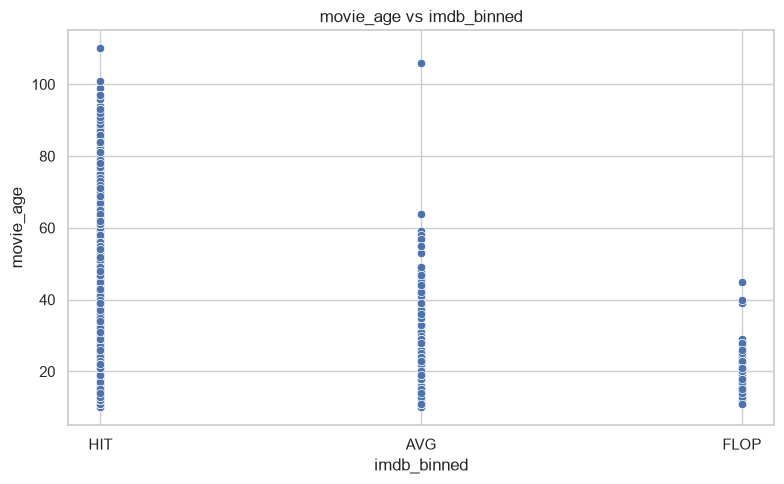

In [29]:
# Scatterplots across Target Categories
for column in num_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=TARGET, y=column)
    plt.title(f"{column} vs {TARGET}")
    plt.tight_layout()
    plt.show()

# Categorical Data Analysis vs Target

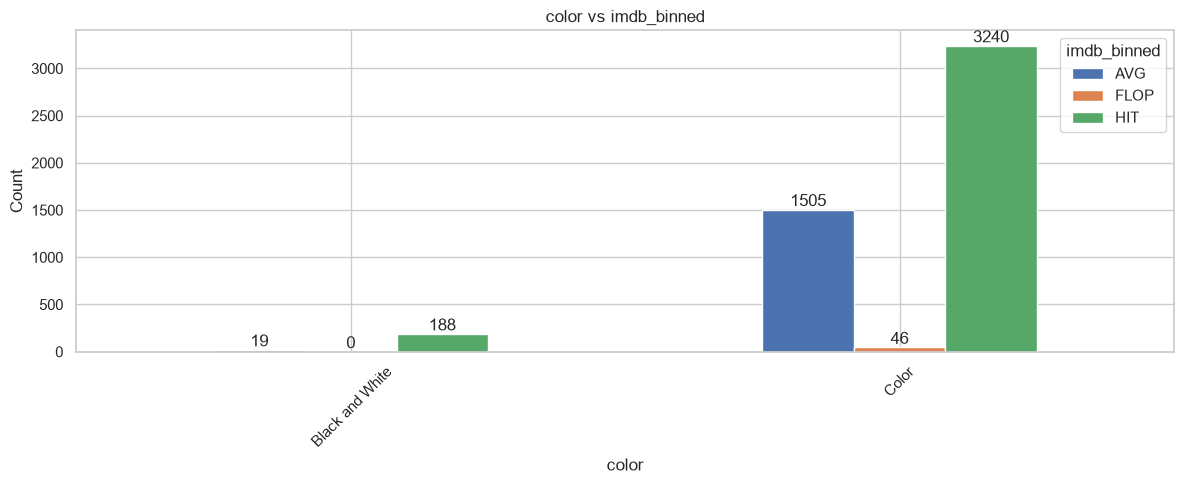

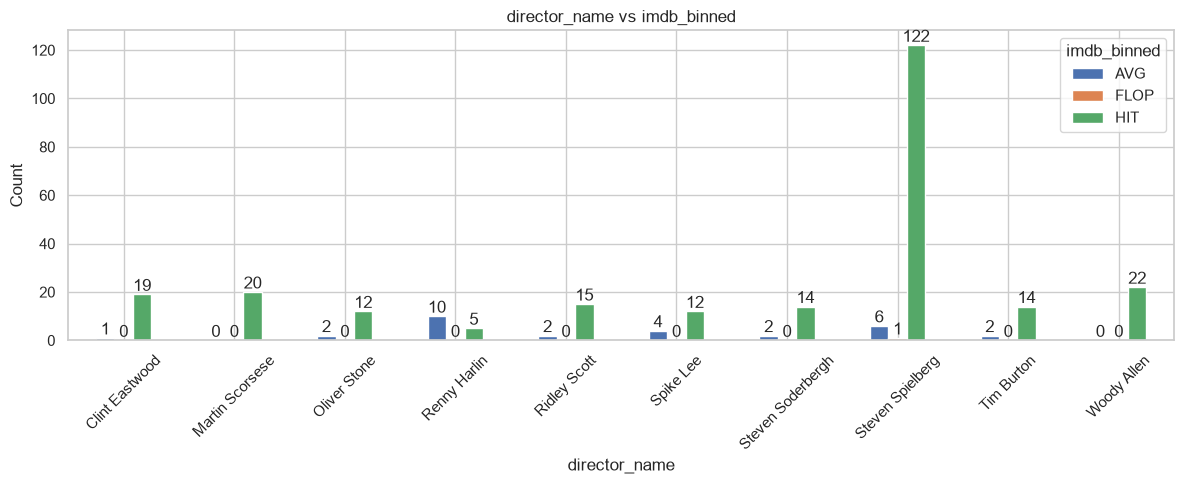

In [ ]:
ignored = [TARGET, "genres", "plot_keywords"]

for column in cat_cols:
    if column not in ignored:
        top = df[column].value_counts().head(TOP_N).index
        temp = df[df[column].isin(top)]

        ct = pd.crosstab(temp[column], temp[TARGET])

        ax = ct.plot(kind="bar", figsize=(12, 5))

        for container in ax.containers:
            ax.bar_label(container)

        plt.title(f"{column} vs {TARGET}")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Correlation Matrix Analysis

In [ ]:

if len(num_cols) > 1:
    plt.figure(figsize=(20,25))
    sns.heatmap(
        df[num_cols].corr(),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()